# Assignment 1 COMP 6934 W26

This data set has many analyses available on [kaggle](https://www.kaggle.com/), a site which supports the data science community with datasets and worked data analyses, including jupyter notebooks. So you can find lots of work on the dataset; but recall the submitted work policy from the course outline: if you copy or share materials and ideas without attribution, I will consider it to be academic misconduct and serious penalties may be applied.

From the [data set page on kaggle](https://www.kaggle.com/datasets/schran/insurance-premium-prediction/data), you can find more information on the data and links to notebooks that have a variety of analyses on the data. Again, if you draw content of ideas from these pages, make sure to attribute them.

As well as completing the notebook, marks will be awarded for your visualization choices, within the scope of the material covered in class lecture and the instructions given below.

I am providing the rest of the notebook as a starting point for your submission.


# Introduction

In this section, indicate the following: the subject matter and the goals of this notebook, the source of the data, and what analysis or visualization are included in the notebook. In this case, you should also note any cleaning required to the data prior to computation.

The ostensible purpose for the notebook is to explore **the influence of age and other factors on insurance premiums**

Also indicate which columns of the data set will be included in your analysis and visuals.

You are required to use age, policy type, and (of course) premium data columns in your analysis. Include data from two additional columns in your analyses.

You should produce at least four different types of plots.

## Data definition


In [133]:
import pandas as pd

In [134]:
medDF = pd.read_csv("./datasets/InsuranceAlternate.csv")
medDF.info()

<class 'pandas.DataFrame'>
RangeIndex: 278860 entries, 0 to 278859
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Age                   274175 non-null  float64
 1   Gender                278860 non-null  str    
 2   Annual Income         264905 non-null  float64
 3   Marital Status        273841 non-null  str    
 4   Number of Dependents  250974 non-null  float64
 5   Education Level       278860 non-null  str    
 6   Occupation            197572 non-null  str    
 7   Health Score          268263 non-null  float64
 8   Location              278860 non-null  str    
 9   Policy Type           278860 non-null  str    
 10  Previous Claims       197572 non-null  float64
 11  Vehicle Age           278860 non-null  int64  
 12  Credit Score          250974 non-null  float64
 13  Insurance Duration    278860 non-null  int64  
 14  Premium Amount        274175 non-null  float64
 15  Policy Star

Here you should concisely explain each of the five columns of the data set you are using in detail, so the reader will be able to interpret your plots.


The summary stats for the required columns are:


In [135]:
medDF.head()

,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Premium Amount,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type
0,56.0,Male,99990.0,Married,1.0,Master's,NaN,31.074627,Urban,Comprehensive,NaN,13,320.0,5,1730.377666,2022-12-10 15:21:39.078837,Poor,Yes,Daily,Condo
1,46.0,Male,2867.0,Single,1.0,Bachelor's,NaN,50.271335,Urban,Comprehensive,NaN,3,694.0,4,2157.532850,2023-01-31 15:21:39.078837,Good,Yes,Monthly,House
2,32.0,Female,30154.0,Divorced,3.0,Bachelor's,NaN,14.714909,Suburban,Comprehensive,2.0,16,652.0,8,1421.938280,2023-11-26 15:21:39.078837,Poor,No,Monthly,House
3,60.0,Female,48371.0,Divorced,0.0,PhD,Self-Employed,25.346926,Rural,Comprehensive,1.0,11,330.0,7,924.873021,2023-02-27 15:21:39.078837,Poor,No,Rarely,Condo
4,25.0,Female,54174.0,Divorced,0.0,High School,Self-Employed,6.659499,Urban,Comprehensive,NaN,9,NaN,8,1123.173324,2020-11-25 15:21:39.078837,Poor,No,Rarely,Condo


In [136]:
medDF[["Premium Amount", "Age", "Policy Type"]].describe()

,Premium Amount,Age
count,274175.000000,274175.000000
mean,1472.805180,41.020771
std,595.523044,13.549683
min,56.907419,18.000000
25%,1002.566492,29.000000
50%,1456.809327,41.000000
75%,1946.207655,53.000000
max,3243.231215,64.000000


In [137]:
medDF["Policy Type"].value_counts()

Policy Type
Premium          93298
Basic            93083
Comprehensive    92479
Name: count, dtype: int64

## Instructions

Use the notebook to conduct a study of the dataset to examine the influence of different factors on insurance charges by creating relevant plots.

Divide your notebook into sections, each section containing an exploratory plot (exploring the dataset and the purpose of the notebnook). You should include at least one plot of each type covered in the notes, i.e.

- line
- scatter
- bar
- boxplot

Before conducting any exploratory plots, you should classify each column you use from the data set according to the TNOIR system

Before each plot, consider examining the data in tabular format to get a sense of the data composition. Indicate the purpose of the plot in exploring the data set, and why the particular type of plot is appropriate in terms of the data types and what you are trying to reveal by this plot.

Make sure your plots labels are helpful.

After each plot, indicate what, if anything, the plot reveals about the dataset and factors influencing insurance charges.


In [138]:
import matplotlib.pyplot as plt
import numpy as np

**Description**

- Age: Age of the insured individual (Numerical)
- Policy Type: Type of insurance policy (Categorical: Basic, Comprehensive, Premium)
- Premium Amount: Target variable representing the insurance premium amount (Numerical, skewed)
- Credit Score: Credit score of the insured individual (Numerical, with missing values)
- Smoking Status: Smoking status of the insured individual (Categorical: Yes, No)

**TNOIR system (Text, Nominal, Ordinal, Interval, Ratio):**

| Variable       | TNOIR Type |
| -------------- | ---------- |
| Age            | Ratio      |
| Policy Type    | Nominal    |
| Premium Amount | Ratio      |
| Credit Score   | Ratio      |
| Smoking Status | Nominal    |


In [139]:
# columns for analysis and visualization
selected_columns = [
    "Age",
    "Premium Amount",
    "Policy Type",
    "Smoking Status",
    "Credit Score",
]

# drop missing values
analysis_df = medDF[selected_columns].dropna()

print(f"Original dataset size: {len(medDF)} rows")
print(f"Cleaned dataset size: {len(analysis_df)} rows")

Original dataset size: 278860 rows
Cleaned dataset size: 246733 rows


In [140]:
# looking at features after cleaning
analysis_df.describe()

,Age,Premium Amount,Credit Score
count,246733.000000,246733.000000,246733.000000
mean,41.016236,1472.625220,574.413824
std,13.551296,595.297481,158.799164
min,18.000000,56.907419,300.000000
25%,29.000000,1002.681315,437.000000
50%,41.000000,1456.249338,575.000000
75%,53.000000,1945.318187,712.000000
max,64.000000,3243.231215,849.000000


## 1. Scatter Plot

### Premium Amount vs Credit Score


In [141]:
analysis_df[["Credit Score", "Premium Amount"]].head()

,Credit Score,Premium Amount
0,320.0,1730.377666
1,694.0,2157.532850
2,652.0,1421.938280
3,330.0,924.873021
5,521.0,647.180975


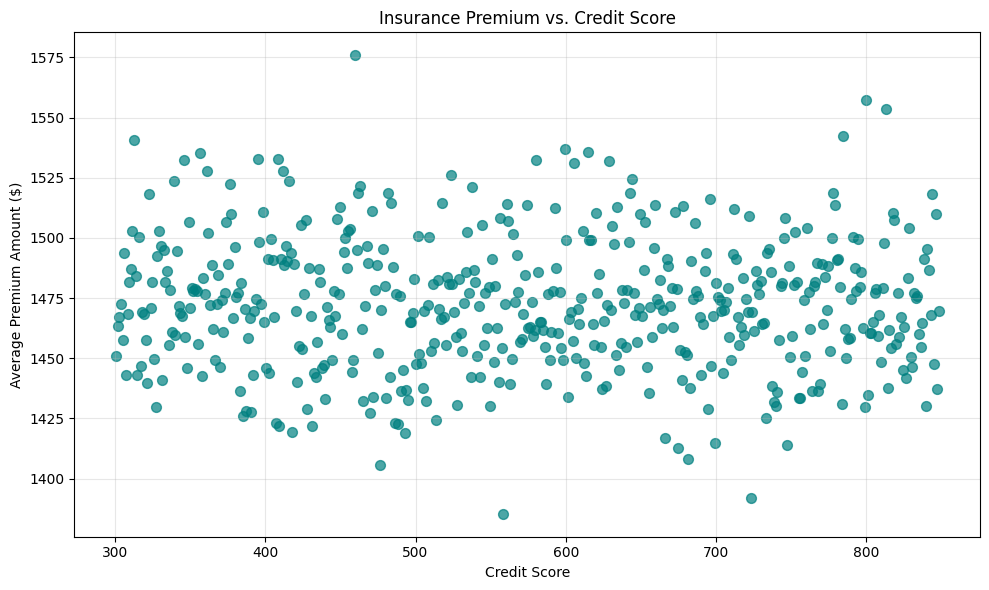

In [154]:
# Bin credit scores and aggregate
credit_bins = pd.cut(analysis_df["Credit Score"], bins=500)
credit_aggregated = (
    analysis_df.groupby(credit_bins, observed=True)["Premium Amount"]
    .mean()
    .reset_index()
)
credit_aggregated["Credit Midpoint"] = credit_aggregated["Credit Score"].apply(
    lambda x: x.mid
)

plt.figure(figsize=(10, 6))
plt.scatter(
    credit_aggregated["Credit Midpoint"],
    credit_aggregated["Premium Amount"],
    s=50,
    alpha=0.7,
    color="teal",
)
plt.xlabel("Credit Score")
plt.ylabel("Average Premium Amount ($)")
plt.title("Insurance Premium vs. Credit Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This scatter plot explores the relationship between policyholder credit score and average premium amount. Credit score is a continuous ratio variable (ranging from 300-850) that may reflect financial responsibility and risk profile. A scatter plot is appropriate here because we are examining the relationship between two continuous variables after aggregating premiums into credit score bins to reduce overplotting and reveal underlying patterns. Insurance companies sometimes use credit scores as a proxy for risk assessment, so this visualization tests whether higher credit scores correlate with lower premiums (better risk = lower cost) or if credit score has minimal impact on pricing in this dataset.

**Conclusion**

The scatter plot reveals no clear relationship between credit score and premium amount. The average premiums remain relatively flat across the entire credit score range (300-850). I expected lower credit scores (indicating higher financial risk) to be associated with higher premiums, or vice versa, higher credit scores to receive premium discounts. However, the data shows neither pattern—premiums appear essentially independent of credit score.


## 2. Box Plot

### Premium Amount by Policy Type


In [143]:
analysis_df.groupby("Policy Type")["Premium Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Policy Type,,,,,,,,
Basic,82376.0,1305.687222,615.030049,56.907419,818.292976,1264.164775,1743.337584,3242.329937
Comprehensive,81870.0,1484.262020,578.567895,267.393977,1019.851878,1466.890698,1949.696283,3202.263076
Premium,82487.0,1627.788817,545.881646,434.953685,1187.050364,1627.330435,2078.637579,3243.231215


In [144]:
analysis_df["Policy Type"].unique()

<StringArray>
['Comprehensive', 'Premium', 'Basic']
Length: 3, dtype: str

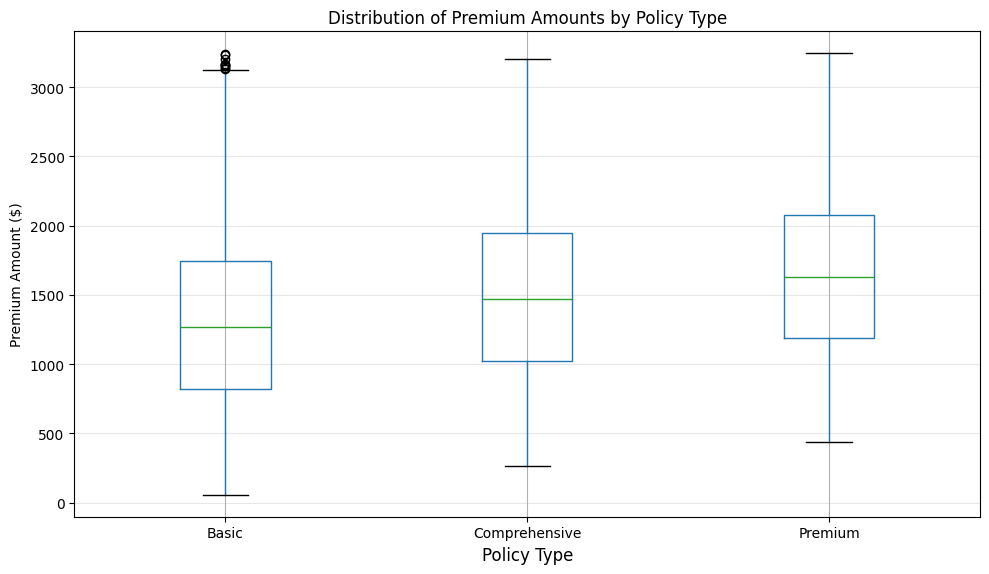

In [145]:
# box plot
analysis_df.boxplot(column="Premium Amount", by="Policy Type", figsize=(10, 6))
plt.ylabel("Premium Amount ($)")
plt.xlabel("Policy Type", fontsize=12)
plt.title("Distribution of Premium Amounts by Policy Type")
plt.suptitle("")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

This box plot compares the distribution of premium amounts across the three policy types: Basic, Premium, and Comprehensive. A box plot is the appropriate visualization choice because it allows comparison of a continuous ratio variable (premium amount) across categorical nominal groups (policy type). The box plot reveals not only the central tendency (median) but also the spread (interquartile range), range (whiskers), and outliers for each policy type, providing a comprehensive view of how premium distributions differ across coverage levels.

**Conclusion**
The box plot reveals that the three policy types show modest differences in their premium distributions. The median premiums increase progressively from Basic (approx. $1,250) to Comprehensive (approx. $1,475) to Premium (approx. $1,625), with approximately $200-$250 separating each tier.

In auto insurance, policy types typically represent different levels of coverage: Basic (often liability-only coverage meeting minimum legal requirements), Comprehensive (adding coverage for non-collision events like theft, vandalism, weather damage), and Premium (likely full coverage including collision, comprehensive, and enhanced liability limits).

All three policy types show wide ranges with considerable overlap, and individual premiums can vary by over $2,000 within each category. This pattern indicates that while coverage level does influence base pricing, driver characteristics dominate the final premium calculation.


## 3. Bar Chart

### Premium Amount for Smoking Status


In [146]:
analysis_df["Smoking Status"].unique()

<StringArray>
['Yes', 'No']
Length: 2, dtype: str

In [147]:
# calc mean premium for each smoking status
smoking_stats = analysis_df.groupby("Smoking Status")["Premium Amount"].agg(
    ["mean", "count", "std"]
)
smoking_stats

,mean,count,std
Smoking Status,,,
No,1473.649895,123285,594.825193
Yes,1471.601897,123448,595.769423


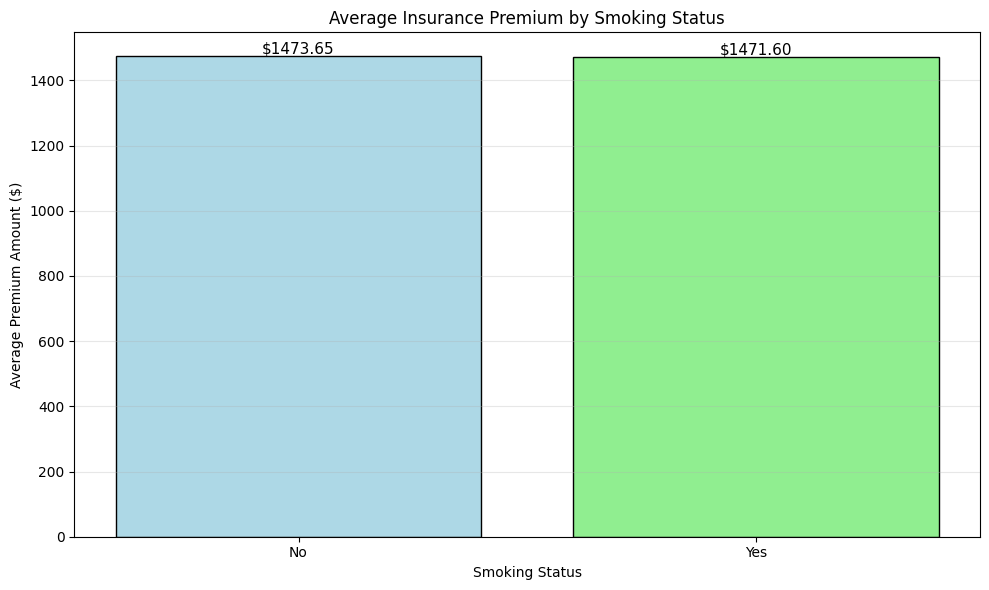

In [148]:
# bar chart
plt.figure(figsize=(10, 6))
mean_premiums = analysis_df.groupby("Smoking Status")["Premium Amount"].mean()
bars = plt.bar(
    mean_premiums.index,
    mean_premiums.values,
    color=["lightblue", "lightgreen"],
    edgecolor="black",
)

# add label to the top bars
for i, (label, value) in enumerate(mean_premiums.items()):
    plt.text(
        i,
        value,
        f"${value:.2f}",
        ha="center",
        va="bottom",
        fontsize=11,
    )

plt.ylabel("Average Premium Amount ($)")
plt.xlabel("Smoking Status")
plt.title("Average Insurance Premium by Smoking Status")
plt.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

This bar chart compares the average premium amounts between smokers and non-smokers. A bar chart is appropriate for this comparison because we are displaying aggregated summary statistics (mean premium amounts) across two categories of a nominal variable (smoking status: Yes/No).

**Conclusion**

The bar chart reveals an expected finding for auto insurance: smokers and non-smokers pay identical average premiums, with difference of only $2.05.

Auto insurance pricing is built around factors that directly predict collision likelihood and claim severity. Insurers focus on observable driving-related risk factors rather than lifestyle choices that lack clear predictive power for crashes. Including smoking status would add complexity to the rating algorithm without meaningfully improving risk prediction, and could raise fairness concerns about using health behaviors to price a product unrelated to health outcomes. This finding is consistent with industry best practices and expectations that rating factors must be non-discriminatory.


## 4. Line Plot

### Premium Amount by Age Group


In [149]:
# Create age group bins
age_bins = [18, 25, 30, 35, 40, 45, 50, 55, 60, 65]
age_labels = [
    "18-24",
    "25-29",
    "30-34",
    "35-39",
    "40-44",
    "45-49",
    "50-54",
    "55-59",
    "60-64",
]
analysis_df["Age Group"] = pd.cut(
    analysis_df["Age"], bins=age_bins, labels=age_labels, include_lowest=True
)

# calc mean premium by age group
age_group_stats = analysis_df.groupby("Age Group", observed=True)["Premium Amount"].agg(
    ["mean", "count"]
)
age_group_stats

,mean,count
Age Group,,
18-24,1662.817298,41796
25-29,1601.323706,26141
30-34,1554.067150,26544
35-39,1505.130940,26362
40-44,1453.982654,26118
45-49,1411.196274,26183
50-54,1354.477833,26412
55-59,1300.987550,26203
60-64,1252.397589,20974


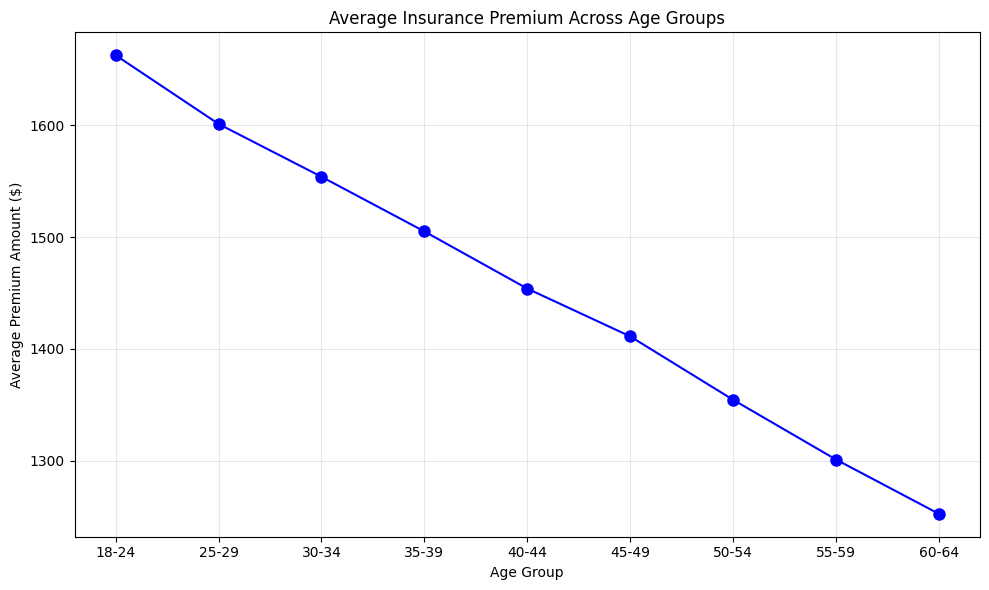

In [150]:
# line plot
plt.figure(figsize=(10, 6))
mean_premium_by_age = analysis_df.groupby("Age Group")["Premium Amount"].mean()
plt.plot(
    mean_premium_by_age.index,
    mean_premium_by_age.values,
    marker="o",
    markersize=8,
    color="blue",
)

plt.ylabel("Average Premium Amount ($)")
plt.xlabel("Age Group")
plt.title("Average Insurance Premium Across Age Groups")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

This line plot displays the trend of average premium amounts across different age groups, from youngest (18-24) to oldest (60-64). A line plot is appropriate here because we are visualizing a trend across an ordered age groups progress chronologically from young to old, creating a natural ordering. By binning individual ages into groups and calculating mean premiums for each bin, we can clearly reveal how insurance costs change across the lifespan while reducing noise from individual data points.

**Conclusion**

The line plot reveals a strong negative relationship between age and average premium amount, which is a major characteristic of auto insurance pricing. The youngest age group (18-24) pays the highest average premium at approximately $1,675, while premiums decline steadily and nearly linearly across each successive age bracket, reaching approximately $1,250 for the oldest group (60-64).

This pattern perfectly aligns with auto insurance principles. Young drivers, particularly those under 25, represent the highest-risk group due to inexperience behind the wheel, higher rates of distracted driving, greater likelihood of speeding, and statistically elevated crash rates. Insurance companies charge substantially higher premiums to offset the expected claims from this demographic. As drivers age and accumulate years of safe driving history, their risk profiles improve dramatically. By their 30s and 40s, most drivers have developed defensive driving skills and demonstrate more cautious behavior, resulting in fewer accidents and lower claims.


## Conclusion about visualizations

In this section, make a short comment (two to three sentences) about how the visualizations in your submission might be improved. You do not have to restrict yourself to


# Attributions

Be sure to add your own sources or indicate you have none to add. Sources can be web sites, text materials, and so on. They do not have to be hyperlinks. Other people are also sources, but they are not allowed for in class credit problems.

| Source           | What is it                                                                               | How used                                                                                                 |
| ---------------- | ---------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------- |
| source goes here | information, analysis ideas, data, code, plots are examples.                             | did you copy content, use suggestions, or follow a strategy, and where in your submission does it appear |
| Google           | how do remove automatic plot titles generated. eg. `plt.subtitle(" ")`                   | followed instructions                                                                                    |
| Youtube          | [How to display values on Bar Chart Python](https://www.youtube.com/watch?v=orQWVU4Wbkw) | followed video instruction                                                                               |
